In [37]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')


In [75]:
# Load dataset
df = pd.read_csv("rainfall_disaster_prediction_dataset.csv")

In [77]:
df.head()

,Location,Temperature (°C),Humidity (%),Pressure (hPa),Wind Speed (km/h),Rainfall (mm),Disaster Risk,Nearby Risk Areas,Prediction Result
0,Vellore,27.66,53,1006,16.73,2,No Immediate Risk,NaN,Rainfall: 2mm and No Immediate Risk. Nearby ri...
1,Thoothukudi,20.27,95,1011,15.68,26,Flood Risk Possible,"Kayalpattinam, Srivaikuntam",Rainfall: 26mm and Flood Risk Possible. Nearby...
2,Salem,30.35,54,1010,25.63,8,No Immediate Risk,NaN,Rainfall: 8mm and No Immediate Risk. Nearby ri...
3,Tiruchirappalli,33.22,95,1016,7.58,44,Flood Risk Possible,"Srirangam, Manapparai",Rainfall: 44mm and Flood Risk Possible. Nearby...
4,Erode,33.65,85,996,25.71,42,Flood Risk Possible,"Perundurai, Bhavani",Rainfall: 42mm and Flood Risk Possible. Nearby...


In [79]:
df.shape

(2000, 9)

In [83]:
df.info()       # Check datatypes & non-null

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Location           2000 non-null   object 
 1   Temperature (°C)   2000 non-null   float64
 2   Humidity (%)       2000 non-null   int64  
 3   Pressure (hPa)     2000 non-null   int64  
 4   Wind Speed (km/h)  2000 non-null   float64
 5   Rainfall (mm)      2000 non-null   int64  
 6   Disaster Risk      2000 non-null   object 
 7   Nearby Risk Areas  630 non-null    object 
 8   Prediction Result  2000 non-null   object 
dtypes: float64(2), int64(3), object(4)
memory usage: 140.8+ KB


In [85]:
df.describe()   # Summary stats

,Temperature (°C),Humidity (%),Pressure (hPa),Wind Speed (km/h),Rainfall (mm)
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,30.052355,64.924000,1007.604500,14.948490,18.012000
std,5.690523,20.471169,10.340142,8.670919,14.527952
min,20.020000,30.000000,990.000000,0.000000,0.000000
25%,25.270000,46.000000,999.000000,7.555000,6.000000
50%,30.020000,65.000000,1007.000000,14.875000,14.000000
75%,34.862500,83.000000,1017.000000,22.522500,28.000000
max,39.990000,100.000000,1025.000000,29.980000,50.000000


In [87]:
df.isnull().sum()

Location                0
Temperature (°C)        0
Humidity (%)            0
Pressure (hPa)          0
Wind Speed (km/h)       0
Rainfall (mm)           0
Disaster Risk           0
Nearby Risk Areas    1370
Prediction Result       0
dtype: int64

In [89]:
# Drop unnecessary columns
df = df.drop(columns=["Prediction Result", "Nearby Risk Areas"])

In [91]:
df.isnull().sum()

Location             0
Temperature (°C)     0
Humidity (%)         0
Pressure (hPa)       0
Wind Speed (km/h)    0
Rainfall (mm)        0
Disaster Risk        0
dtype: int64

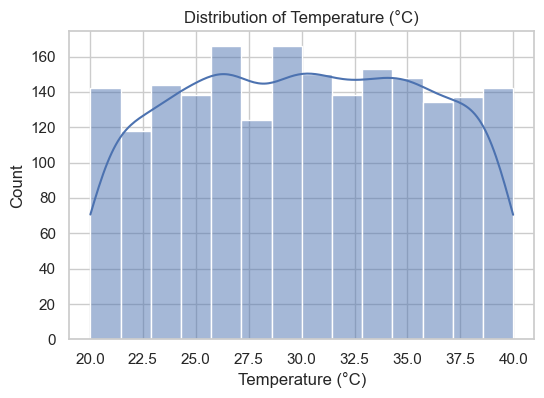

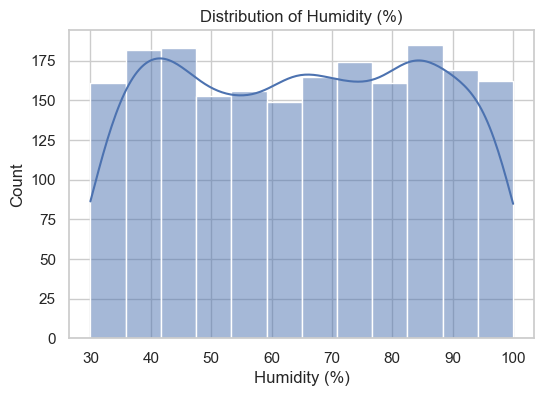

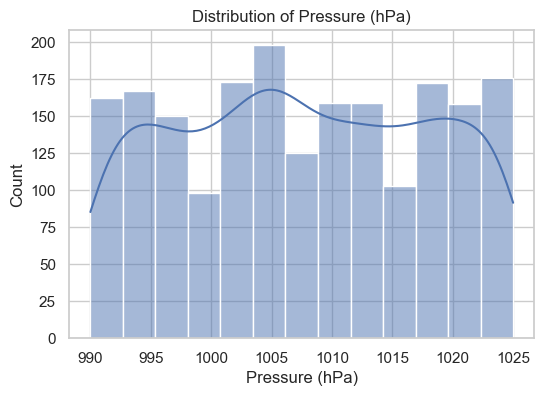

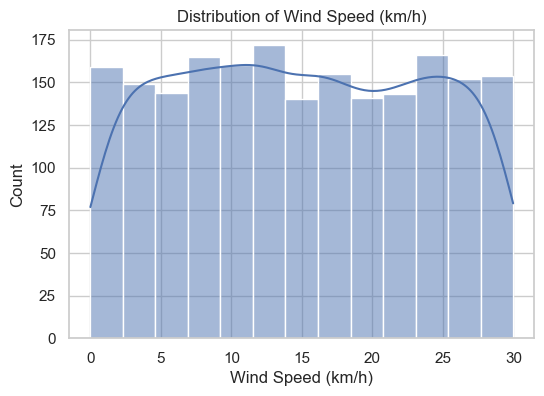

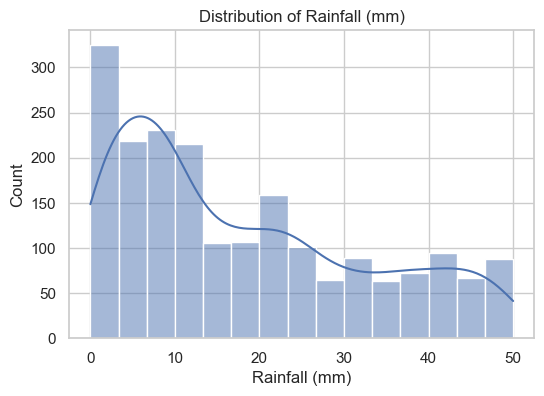

In [93]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set style
sns.set(style="whitegrid")

# Plot distribution of numerical features
num_cols = ['Temperature (°C)', 'Humidity (%)', 'Pressure (hPa)', 'Wind Speed (km/h)', 'Rainfall (mm)']
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


In [94]:
# Encode 'Location' (feature) and 'Disaster Risk' (label)
le_location = LabelEncoder()
df["Location"] = le_location.fit_transform(df["Location"])

le_risk = LabelEncoder()
df["Disaster Risk"] = le_risk.fit_transform(df["Disaster Risk"])

In [97]:
# Define features and targets
X = df.drop(columns=["Disaster Risk", "Rainfall (mm)"])  # Features
y_risk = df["Disaster Risk"]                             # Classification label
y_rainfall = df["Rainfall (mm)"]                         # Regression label


In [99]:

# Split data for classification
X_train_risk, X_test_risk, y_train_risk, y_test_risk = train_test_split(X, y_risk, test_size=0.2, random_state=42)

# Split data for regression
X_train_rain, X_test_rain, y_train_rain, y_test_rain = train_test_split(X, y_rainfall, test_size=0.2, random_state=42)


In [101]:
# Train Classification Model (Disaster Risk)
clf = RandomForestClassifier()
clf.fit(X_train_risk, y_train_risk)
y_pred_risk = clf.predict(X_test_risk)
acc_clf = accuracy_score(y_test_risk, y_pred_risk)*100

print("=== Disaster Risk Classification ===")
print(classification_report(y_test_risk, y_pred_risk))
print("Accuracy:", acc_clf,"%")

=== Disaster Risk Classification ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         8
           1       1.00      1.00      1.00       135
           2       0.97      1.00      0.98       257

    accuracy                           0.98       400
   macro avg       0.66      0.67      0.66       400
weighted avg       0.96      0.98      0.97       400

Accuracy: 98.0 %


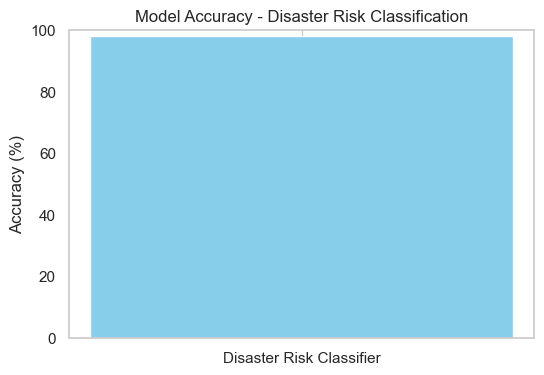

In [103]:
import matplotlib.pyplot as plt

# Calculate accuracy
acc_clf = accuracy_score(y_test_risk, y_pred_risk) * 100

# Create bar chart
plt.figure(figsize=(6, 4))
plt.bar(["Disaster Risk Classifier"], [acc_clf], color='skyblue')
plt.ylim(0, 100)
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy - Disaster Risk Classification")
plt.grid(axis='y')
plt.show()


In [105]:
# Train Regression Model (Rainfall)
reg = RandomForestRegressor()
reg.fit(X_train_rain, y_train_rain)
y_pred_rain = reg.predict(X_test_rain)
acc_reg = r2_score(y_test_rain, y_pred_rain)*100

print("\n=== Rainfall Prediction ===")
print("Mean Absolute Error:", mean_absolute_error(y_test_rain, y_pred_rain))
print("R² Score:", acc_reg,"%")



=== Rainfall Prediction ===
Mean Absolute Error: 4.566050000000001
R² Score: 83.80012943659005 %


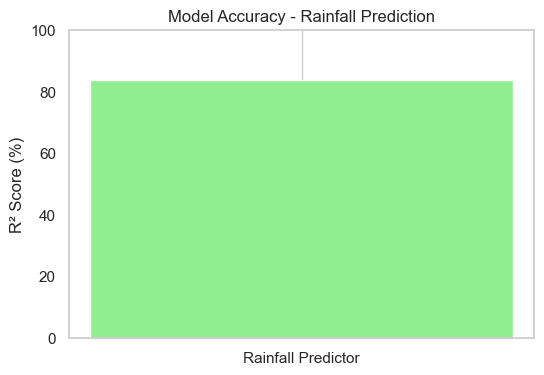

In [107]:
import matplotlib.pyplot as plt

# Accuracy (R² score already calculated as acc_reg)
labels = ['Rainfall Predictor']
scores = [acc_reg]  # R² score in percentage

# Plot the bar chart
plt.figure(figsize=(6, 4))
plt.bar(labels, scores, color='lightgreen')
plt.ylim(0, 100)
plt.ylabel("R² Score (%)")
plt.title("Model Accuracy - Rainfall Prediction")
plt.grid(axis='y')
plt.show()


In [109]:

# Save models and encoders
joblib.dump(clf, "disaster_risk_classifier.pkl")
joblib.dump(reg, "rainfall_predictor.pkl")
joblib.dump(le_location, "location_encoder.pkl")
joblib.dump(le_risk, "risk_encoder.pkl")

print("\n✅ Models and encoders saved successfully.")



✅ Models and encoders saved successfully.
